In [ ]:
!pip install stim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 29.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import stim
import matplotlib.pyplot as plt
from multiprocessing import Pool, cpu_count
from scipy import stats

# **1. Introduction**

In [ ]:
#GHZ state

def ghz_tableau(n):
    """
    Creates a stim.Tableau representing a GHZ state for 'n' qubits.
    The GHZ state is defined as (|00...0> + |11...1>) / sqrt(2).
    """
    # Initialize an empty stim circuit
    c = stim.Circuit()

    # Step 1: Put the first qubit (q0) into a superposition state using a Hadamard gate
    # State changes from |0> to (|0> + |1>) / sqrt(2)
    c.append("H", 0)

    # Step 2: Propagate the entanglement to all other qubits using a chain of CNOT gates
    # Each CNOT uses qubit 'i' as control and 'i+1' as target
    for i in range(n - 1):
        c.append("CNOT", [i, i + 1])

    # Convert the circuit instructions into a Tableau representation
    # Tableaus are an efficient way to store Clifford states using stabilizer formalism
    tab = stim.Tableau.from_circuit(c)
    return tab

# --- Main Execution ---

num_qubits = 4
# Generate the Tableau for a 4-qubit GHZ state
tab = ghz_tableau(num_qubits)

# Print the Tableau (shows X and Z stabilizers)
print("Tableau representation of the GHZ state:")
print(tab)

# Initialize the Tableau Simulator
ghz_state = stim.TableauSimulator();

# Set the number of qubits in the simulator (initial state is |0000>)
ghz_state.set_num_qubits(num_qubits)

# Apply the GHZ transformations to the simulator's internal state
# We apply the operations defined in 'tab' to qubits 0, 1, 2, and 3
ghz_state.do_tableau(tab, range(num_qubits))

# Extract the full State Vector from the stabilizer representation
# Note: This is only feasible for small N (N < 25) due to exponential memory cost
print("\nFull State Vector (Amplitudes):")
ghz_state.state_vector()


# Solo el primer elemento (|0000\) y el último (|1111\) tienen valor (\frac{1}{\sqrt{2}} \approx 0.707).
# Todos los estados intermedios son cero.

Tableau representation of the GHZ state:
+-xz-xz-xz-xz-
| ++ ++ ++ ++
| ZX _Z __ __
| _X XZ _Z __
| _X X_ XZ _Z
| _X X_ X_ XZ

Full State Vector (Amplitudes):


array([0.70710677+0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.        +0.j,
       0.        +0.j, 0.        +0.j, 0.        +0.j, 0.70710677+0.j],
      dtype=complex64)

In [ ]:
# Random Clifford layer

def RandomCliffordBrickworkLayer(N: int) -> stim.Tableau:
    """
    Creates a single layer of random 2-qubit Clifford gates arranged
    in a 'brickwork' pattern (even pairs, then odd pairs).
    """
    # Initialize a global identity Tableau for N qubits
    uGlobal = stim.Tableau(N)

    # Define the 'brickwork' geometry:
    # 1. Even pairs: [0,1], [2,3], [4,5]...
    # 2. Odd pairs:  [1,2], [3,4], [5,6]...
    # np.concatenate joins these two sets of pairs into a single order of operations
    siteOrder = np.concatenate((
        [[j, j+1] for j in np.arange(0, N-1, 2)], # Even bonds
        [[j, j+1] for j in np.arange(1, N-1, 2)]  # Odd bonds
    ))

    # Iterate through each pair and apply a random 2-qubit Clifford gate
    for pair in siteOrder:
        # stim.Tableau.random(2) generates a random element from the Clifford group for 2 qubits.
        uGlobal.append(stim.Tableau.random(2), pair)

    return uGlobal

In [ ]:
N = 4;
# Generate one complete brickwork layer (even + odd pairs)
# filled with random 2-qubit Clifford unitaries
op = RandomCliffordBrickworkLayer(N)

# Printing the Tableau reveals the stabilizer and destabilizer generators
print("Global Unitary Tableau (Stabilizer Representation):")
print(op)

Global Unitary Tableau (Stabilizer Representation):
+-xz-xz-xz-xz-
| -+ ++ -- -+
| XZ X_ __ __
| _Z ZZ ZX Y_
| _Z XZ _Y Y_
| __ __ XX ZX


In [ ]:
# 1. Initialize the base simulator with N qubits
# By default, all qubits start in the |00...0> state
state = stim.TableauSimulator()
state.set_num_qubits(N)

# 2. Create a copy of the initial state
# This is useful if you want to reuse the 'clean' |0> state later
outputState = state.copy()

# 3. Apply the 'op' (Random Clifford Brickwork Layer) to all qubits (0 to N-1)
# This mutates 'outputState' by performing the Clifford transformations
# defined in our 'op' Tableau
outputState.do_tableau(op, range(N))

# 4. Print the current stabilizer state of the simulator
print(outputState)

In [ ]:
# Returns the expectation value of the Z operator on qubit 2
# Result is: +1 (if state is |0>), -1 (if state is |1>), or 0 (if in superposition)
result = outputState.peek_z(2)

print(f"Expectation value of Z on qubit 2: {result}")

Expectation value of Z on qubit 2: 0


In [ ]:
# Functions

def pauli_string_to_binary_row(ps: stim.PauliString):
    """
    Maps a stim.PauliString (I, X, Y, Z) to a binary row vector of length 2N.
    Format: [X1, X2, ..., Xn | Z1, Z2, ..., Zn]
    """
    n = len(ps)
    X = np.zeros(n, dtype=np.uint8)
    Z = np.zeros(n, dtype=np.uint8)

    for i in range(n):
        pauli = ps[i]  # Mapping: 0=I, 1=X, 2=Y, 3=Z
        # Y is represented as having both X and Z components (Y = iXZ)
        if pauli == 1 or pauli == 2:  # X or Y component
            X[i] = 1
        if pauli == 3 or pauli == 2:  # Z or Y component
            Z[i] = 1

    return np.concatenate([X, Z])



def full_stabilizer_binary_matrix(state: stim.TableauSimulator):
    """
    Extracts the full stabilizer group from the simulator and
    arranges it into an N x 2N binary matrix.
    """
    # canonical_stabilizers() returns a simplified, independent set of generators
    stabilizers = state.canonical_stabilizers()
    N = len(stabilizers)
    n = state.num_qubits

    mat = np.zeros((N, 2 * n), dtype=np.uint8)

    # 'stabilizers' is a list of PauliStrings (e.g., [X0X1, Z0Z1, ...])
    # 'mat' is a pre-allocated NumPy array of zeros with shape (N, 2*N)

    for i, stab in enumerate(stabilizers):
    # 1. 'enumerate' gives us both the index 'i' (0, 1, 2...) and the stabilizer 'stab'
    # 2. We call our previous function to convert the PauliString into a binary row
    # 3. We store that binary row in the i-th row of our matrix 'mat'
      mat[i] = pauli_string_to_binary_row(stab)

    # Finally, we return the complete N x 2N binary parity-check matrix
    return mat



def restrict_matrix_to_subsystem(M, A):
    # restricted binary matrix of the state
    # M: complete binary matrix (N × 2N)
    # A: ist of qubits that belong to the subsystem

    N = M.shape[1] // 2   # Total qubits is half the number of columns
    A = list(A)    # Convert input to a list (e.g., [0, 1] for the first two qubits)

    cols_X = A    # Identify which columns hold the 'X' data for our chosen qubits
    cols_Z = [N + a for a in A]    # Identify which columns hold the 'Z' data for our chosen qubits
                                  # (Z columns start after the last X column, at index N_total)
                                  # Si A=[0, 1] hacemos N+0 y luego N+1

    return M[:, cols_X + cols_Z]



def gf2_rank(mat):
    """
    Calculates the rank of a binary matrix
    """
    mat = mat.copy()
    n_rows, n_cols = mat.shape
    rank = 0
    for col in range(n_cols):
        pivot_rows = np.flatnonzero(mat[rank:, col])
        if pivot_rows.size == 0:
            continue
        pivot_row = pivot_rows[0] + rank
        if pivot_row != rank:
            mat[[rank, pivot_row]] = mat[[pivot_row, rank]]
        mask = mat[:, col].astype(bool)
        mask[rank] = False
        mat[mask] ^= mat[rank]
        rank += 1
    return rank



def entanglement_vs_time(N: int, time_steps: int):
    """
    Simulates the dynamical growth of entanglement entropy S(t) over time.
    At each step, a new random Clifford layer is applied, and the
    entropy of the left half of the system is calculated.
    """
    # N : int. Number of qubits
    # A : Subsystem qubits
    # time_steps : int. Number of time steps

    # 1. Define Subsystem A as the first half of the qubits (0 to N/2 - 1)
    # This is the standard bipartite cut for studying entanglement scaling.
    A = list(range(N // 2))

    # 2. Initialize the simulator starting from the product state |00...0>
    # In this state, there is zero initial entanglement.
    state = stim.TableauSimulator()
    state.set_num_qubits(N)

    # 3. Create an array to store the entropy value at each time step
    S = np.zeros(time_steps)

    for t in range(time_steps):
        # 4. Evolve the state by applying one random brickwork layer
        # Note: A new random layer is generated at every step 't'
        state.do_tableau(RandomCliffordBrickworkLayer(N), range(N))

        # 5. Full binary stabilizer matrix
        M = full_stabilizer_binary_matrix(state)

        # 6. Restrict to Subsystem A
        M_restricted = restrict_matrix_to_subsystem(M, A)

        # 7. Calculate Entanglement Entropy using the GF(2) rank formula:
        # S(t) = Rank(Restricted_Matrix) - Number_of_qubits_in_A
        S[t] = gf2_rank(M_restricted) - len(A)

    return S

In [ ]:
M=full_stabilizer_binary_matrix(ghz_state)
print(M)

A=[0,1]    # Subsystem
M_restricted=restrict_matrix_to_subsystem(M,A)
print(M_restricted)

S = gf2_rank(M_restricted) - len(A)    # Calculate the Entanglement Entropy (S) using the rank formula
# For a GHZ state, any partition should give S = 1 (1 bit of entanglement)
print(f"\nEntanglement Entropy S_A: {S}")

[[1 1 1 1 0 0 0 0]
 [0 0 0 0 1 0 0 1]
 [0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 1 1]]
[[1 1 0 0]
 [0 0 1 0]
 [0 0 0 1]
 [0 0 0 0]]

Entanglement Entropy S_A: 1


# **2. Brickwork Circuit (Local Dynamics)**

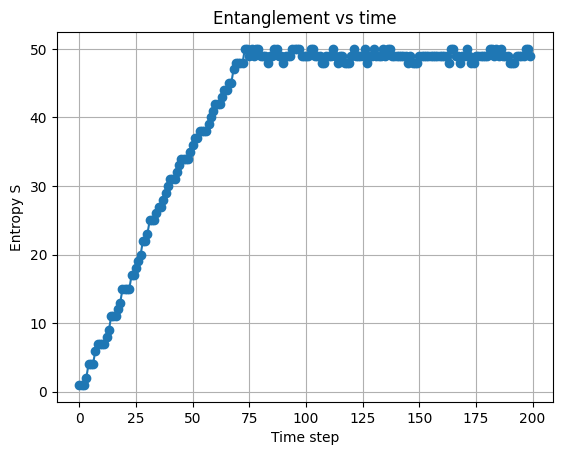

In [ ]:
N = 100
time_steps = 200


S = entanglement_vs_time(N, time_steps)

plt.plot(range(time_steps), S, marker='o')
plt.xlabel("Time step")
plt.ylabel("Entropy S")
plt.title("Entanglement vs time")
plt.grid(True)
plt.show()



In [ ]:
# Saturation time

def get_saturation_time(N, threshold_offset, max_steps):
    """
    Runs a single quantum simulation efficiently and returns the first
    time step 't' where entanglement entropy S(t) reaches the threshold.
    """
    threshold = (N // 2) - threshold_offset

    # 1. Initialize simulator once
    state = stim.TableauSimulator()
    state.set_num_qubits(N)
    A = list(range(N // 2))

    for t in range(max_steps):
        # 2. Evolve the SAME state by one layer at a time
        # Replace 'RandomCliffordBrickworkLayer' with 'WrAA_time_step(N, s)' if needed
        state.do_tableau(RandomCliffordBrickworkLayer(N), range(N))

        # 3. Calculate entropy for current step
        M = full_stabilizer_binary_matrix(state)
        M_restricted = restrict_matrix_to_subsystem(M, A)
        S_t = gf2_rank(M_restricted) - len(A)

        # 4. Check for saturation
        if S_t >= threshold:
            return t + 1

    return max_steps

def estimate_tau_vs_N(Ns, reps=20, threshold_offset=5):
    """
    Ensemble averaging for different system sizes.
    """
    Ns = list(Ns)
    tau_mean = []
    tau_error = []

    for N in Ns:
        max_steps = int(10 * N)
        taus = []

        # Run multiple independent realizations for statistical averaging
        for _ in range(reps):
            tau = get_saturation_time(N, threshold_offset, max_steps)
            taus.append(tau)

        taus_array = np.array(taus)    # Convert to numpy array for statistical analysis
        tau_mean.append(np.mean(taus_array))   # Calculate the ensemble average (Mean)
        # SEM: Standard Error of the Mean
        # Calculate the Standard Error of the Mean (SEM): sigma / sqrt(reps)
        # Using ddof=1 for the sample standard deviation (Bessel's correction)
        tau_error.append(np.std(taus_array, ddof=1) / np.sqrt(reps))

    return np.array(Ns), np.array(tau_mean), np.array(tau_error)

In [ ]:
# Simulation for different N

Ns = np.arange(20, 101, 20)
reps_param=20
offset_param=5

N, tau, error = estimate_tau_vs_N(
    Ns,
    reps=reps_param,
    threshold_offset=offset_param
)


KeyboardInterrupt: 

In [ ]:
plt.errorbar(N, tau, yerr=error, fmt='o--',
             capsize=5,          # Añade los topes horizontales (forma de "I")
             elinewidth=2,       # Hace las líneas del error más gruesas
             markeredgewidth=1,  # Engrosa los topes horizontales
             ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
             alpha=1)            # Asegura que no haya transparencia

plt.title("Linear Scaling of Saturation Time")
plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.grid(True)
plt.show()

# **3. Random Pairing (Non-Local Dynamics)**

In [ ]:
# Layer: global random pairing

def RandomCliffordRandomPairLayer(N: int) -> stim.Tableau:
    """
    ALL-TO-ALL LAYER:
    Creates a random pairing of all N qubits (not just neighbors).
    This simulates long-range interactions where any qubit can talk to any other.
    """
    if N % 2 != 0:
        raise ValueError("N must be even for perfect pairing.")

    uGlobal = stim.Tableau(N)
    # Shuffle the indices to create random pairs
    perm = np.random.permutation(N)

    for i in range(0, N, 2):
        # Apply a random 2-qubit Clifford gate to each pair
        uGlobal.append(stim.Tableau.random(2), [int(perm[i]), int(perm[i+1])])
    return uGlobal

In [ ]:
# OPTIMIZED FUNCTIONS (Using bitsets for high-speed execution)


def gf2_rank_int(rows_as_ints):   # GF(2) rank using integers (bitsets)
    """
    FAST GAUSSIAN ELIMINATION:
    Uses Python's arbitrary-precision integers as bit-vectors.
    The 'basis' dictionary stores the pivot for each bit position.
    """
    basis = {}  # pivot_bit -> vector
    rank = 0
    for v in rows_as_ints:
        v = int(v)
        while v:
            hb = v.bit_length() - 1
            if hb in basis:
                v ^= basis[hb]
            else:
                basis[hb] = v
                rank += 1
                break
    return rank



def restricted_rows_as_ints_from_stabilizers(stabilizers, A):
    """
    Build the restricted stabilizer matrix rows (N rows, 2|A| columns)
    as Python ints. Column order: [X on A | Z on A].
    """
    m = len(A)
    rows = []
    for ps in stabilizers:
        v = 0
        # X part bits [0..m-1], Z part bits [m..2m-1]
        for k, q in enumerate(A):
            p = ps[q]  # 0=I,1=X,2=Y,3=Z
            if p == 1 or p == 2:
                v |= (1 << k)
            if p == 2 or p == 3:
                v |= (1 << (m + k))
        rows.append(v)
    return rows



def entanglement_entropy_half_system_fast(state: stim.TableauSimulator):
    """
    HIGH-SPEED ENTROPY:
    Computes S(A) for the first half of the system using bitsets.
    """
    N = state.num_qubits
    A = list(range(N // 2))
    stabs = state.canonical_stabilizers()
    rows = restricted_rows_as_ints_from_stabilizers(stabs, A)
    r = gf2_rank_int(rows)
    return r - len(A)



# Saturation time: early stopping
def saturation_time_one_run(N: int, threshold_offset, max_steps: int) -> int:
    """
    SCRAMBLING TIME MEASUREMENT:
    Runs the simulation until S(t) reaches the threshold (N/2 - offset).
    Returns the first time step 't' where this happens.
    If never reaches, returns max_steps.
    """
    if N % 2 != 0:
        raise ValueError("N must be even.")
    threshold = (N // 2) - threshold_offset

    state = stim.TableauSimulator()
    state.set_num_qubits(N)

    for t in range(max_steps):
        state.do_tableau(RandomCliffordRandomPairLayer(N), range(N))
        S = entanglement_entropy_half_system_fast(state)
        if S >= threshold:
            return t + 1  # because you already applied one layer in this step
    return max_steps



def estimate_tau_vs_N_fast(Ns, reps=20, threshold_offset=5, max_steps_factor=20.0, seed=0):
    """
    SCALING ANALYSIS:
    Estimates the average saturation time (tau) for different system sizes N.
    Used to see if the scrambling time is logarithmic or linear with N.
    max_steps = ceil(max_steps_factor * log2(N+1))
    """
    if seed is not None:
        np.random.seed(seed)

    Ns = list(Ns)
    tau_mean = []
    tau_error = []

    for N in Ns:
         # Define max time steps based on log(N)
        max_steps = max(5, int(np.ceil(max_steps_factor * np.log2(N + 1))))

        taus = []
        for _ in range(reps):
            taus.append(saturation_time_one_run(N, threshold_offset, max_steps))

        taus_array = np.array(taus, dtype=float)
        tau_mean.append(np.mean(taus_array))
        # SEM: Standard Error of the Mean
        # Calculate the Standard Error of the Mean (SEM): sigma / sqrt(reps)
        # Using ddof=1 for the sample standard deviation (Bessel's correction)
        tau_error.append(np.std(taus_array, ddof=1) / np.sqrt(reps))

    return np.array(Ns), np.array(tau_mean), np.array(tau_error)

In [ ]:
Ns = np.array([20, 40, 80, 180, 320])
Ns = Ns[Ns % 2 == 0]
reps = 50
threshold_offset = 5
max_steps_factor = 25.0

Ns_out, tau_mean, tau_error= estimate_tau_vs_N_fast(
    Ns, reps, threshold_offset,
    max_steps_factor=max_steps_factor, seed=0
    )


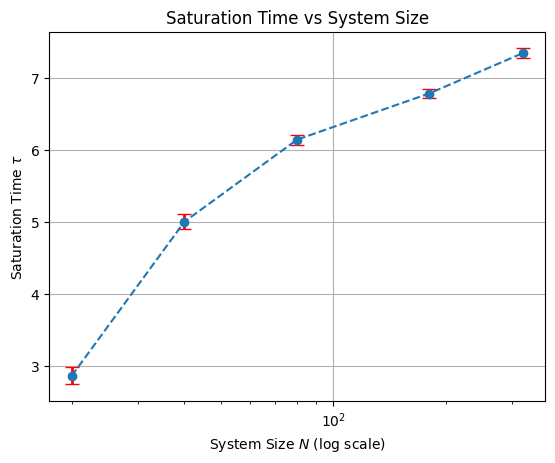

In [ ]:
plt.errorbar(Ns_out, tau_mean, yerr=tau_error, fmt='o--',
             capsize=5,          # Añade los topes horizontales (forma de "I")
             elinewidth=2,       # Hace las líneas del error más gruesas
             markeredgewidth=1,  # Engrosa los topes horizontales
             ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
             alpha=1)            # Asegura que no haya transparencia
plt.title("Saturation Time vs System Size")
plt.xscale('log')
plt.xlabel(r"System Size $N$ (log scale)")
plt.ylabel(r"Saturation Time $\tau$")
plt.grid(True)
plt.show()

# **4. WrAA model**

In [ ]:
# Functions of the model


def wrAA_distance(i: int, j: int, N: int) -> int:
    # Calculates the shortest distance between two qubits on a ring (periodic boundary conditions).
    # The paper treats the qubits as if they are arranged in a circle.
    # If you have 10 qubits, the distance between 0 and 9 is not 9, but 1.
    d = abs(i - j)
    return min(d, N - d)



def wrAA_normalization(N: int, s: float) -> float:
    """
    J_{s,WrAA} from the paper:
    1/J = (N/2)^s + 2 * sum_{d=1}^{N/2 - 1} d^s
    valid for even N.
    """
    denom = float(N // 2) ** s + 2 * sum(float(d) ** s for d in range(1, N // 2))
    return 1.0 / denom



def WrAA_sublayer(N: int, s: float) -> stim.Tableau:
    """
    Selects the partners of each qubit based on the probability d^s, ensuring N/2 gates.

    Generates a single circuit layer where qubits are paired according to
    the probability P(d) ~ d^s.
    - If 's' is large and negative (e.g., -5), gates are mostly nearest-neighbor (Local regime).
    - If 's' is 0, every qubit pair is equally likely (All-to-all/Fast Scrambler regime).
    """

    uGlobal = stim.Tableau(N) # Initializes an empty quantum circuit for N qubits
    available = list(range(N))
    np.random.shuffle(available) # Shuffles the order in which we pick qubits to start pairing

    used = [False] * N # A list of flags to ensure each qubit is used only once
    """
    In the paper, one unit of time t=1 implies that each qubit has interacted once.
    That’s why we shuffle and use a used list, to ensure that we are creating a perfect matching (each qubit has exactly one partner)
    """


    # Iterate through qubits to find a partner for each one (based on distance)
    for i in range(N):
        if used[i]: continue   # If qubit 'i' already has a partner, skip it

        # Possible candidates (unused qubits)
        candidates = [j for j in range(N) if not used[j] and j != i]   # We check which other qubits are free
        if not candidates: break

        # Calculate distances and weights w = d^s
        dists = np.array([wrAA_distance(i, j, N) for j in candidates])   # We compute the geometric distance (on the ring) between our qubit i and all the available candidates
        weights = dists.astype(float) ** s
        prob = weights / weights.sum()  # Normalizes weights so they sum to 1 (probability distribution)
        """
        The wrAA_normalization function J is a global physical constant from the paper to keep the total interaction energy scale invariant.
        In contrast, the normalization inside the loop (weights / weights.sum()) is a statistical requirement:
        it ensures that the available candidates at any given moment form a valid probability distribution (summing to 1)
        so we can pick a partner for the current qubit.
        """
        target = np.random.choice(candidates, p=prob)   # Picks one partner based on those probabilities

        # Apply the gate
        uGlobal.append(stim.Tableau.random(2), [i, target])
        used[i] = True
        used[target] = True

    return uGlobal



def random_perfect_matching(N: int):
    """
    A utility function to create a random pairing of N qubits without
    considering distance. Equivalent to the 's=0' case.
    """
    perm = np.random.permutation(N)
    return [(int(perm[k]), int(perm[k + 1])) for k in range(0, N, 2)]



def WrAA_time_step(N: int, s: float) -> stim.Tableau:
    """
    Defines one unit of time 't=1'.
    In this Clifford model, a single sublayer (where every qubit is touched once)
    is sufficient to represent one discrete time step of the evolution.
    """
    return WrAA_sublayer(N, s)

In [ ]:
def saturation_time_WrAA(N: int, s: float, threshold_offset: int, max_steps: int) -> int:
    """
    Measures the time 't' required for the entanglement entropy to reach saturation.
    In physics, this represents how fast the quantum information 'scrambles'
    across the entire system.
    """
    # The target entropy (threshold) is nearly the maximum possible (N/2).
    # We subtract a small offset because random circuits might stay slightly below
    # the absolute maximum for a few steps.
    threshold = (N // 2) - threshold_offset

    # Initialize the stabilizer state simulator
    state = stim.TableauSimulator()
    state.set_num_qubits(N)

    # Optimization: Calculating the 'rank' (entropy) is computationally expensive.
    # For large systems, we only check the entropy every 5 steps to save time.
    check_every = 1 if N < 100 else 5

    for t in range(max_steps):
        state.do_tableau(WrAA_time_step(N, s), range(N))

        if (t + 1) % check_every == 0:   # Check if it's time to measure the entropy. % es el resto. Si t+1=5 y check_every=5 actúa. Si no no.
            S = entanglement_entropy_half_system_fast(state)
            # If the entropy has reached the threshold, the system is 'saturated'
            if S >= threshold:
                return t + 1   # Return the time step where saturation occurred
    return max_steps    # If it never reaches the threshold, return the maximum allowed steps



def estimate_tau_vs_N_WrAA(Ns, s, reps=20, threshold_offset=5, max_steps_factor=20.0, seed=0):
    """
    Statistical laboratory: Runs multiple simulations for different system sizes (N)
    to see how the saturation time 'tau' scales with the number of qubits.
    This scaling determines the exponent f(s) discussed in the paper.
    """
    if seed is not None:
        np.random.seed(seed)   # Esta instrucción "congela" el azar. A partir de aquí,
                               # todas las parejas que elija WrAA_sublayer y todas las puertas de Clifford serán aleatorias,
                               # pero serán las mismas cada vez que ejecutes el código con esa semilla.

    Ns = list(Ns)
    tau_mean = []
    tau_error = []

    # Loop through each system size (e.g., N=20, 40, 80...)
    for N in Ns:
      # Define a limit for the simulation.
        # For Fast Scramblers (s=0), log(N) is enough.
        # For Local systems (s=-5), this factor should be high enough to allow linear growth.

        # Un límite lineal es más seguro para cubrir ambos regímenes (local y rápido)
        max_steps = int(2.0 * N)

        # Fast: max_steps = max(5, int(np.ceil(max_steps_factor * np.log2(N + 1))))
        # Local: max_steps = max(10, int(np.ceil(max_steps_factor * N)))
        taus = []

        # Repeat the experiment multiple times to get a reliable average
        # since the circuits are random (stochastic).
        for _ in range(reps):
            tau = saturation_time_WrAA(N, s, threshold_offset, max_steps)  # Calculate the saturation time for this specific realization
            taus.append(tau)

        tau_mean.append(np.mean(taus))   # Calculate the average time for the current N
        error_val = np.std(taus, ddof=1) / np.sqrt(reps)   # Calculate the Standard Error: Standard Deviation / sqrt(reps)
        tau_error.append(error_val)

    return np.array(Ns), np.array(tau_mean), np.array(tau_error) # Return the list of sizes and their corresponding average saturation times

### 4.1 WrAA model for $s\to -\infty$ (local)

In [ ]:
Ns = np.array([20, 40, 80, 120, 160])
Ns = Ns[Ns % 2 == 0]

reps_param = 20
offset_param = 5
steps_factor = 8.0

Ns_local, tau_local, error_local = estimate_tau_vs_N_WrAA(
    Ns,
    s=-(10**3),
    reps=reps_param,
    threshold_offset=offset_param,
    max_steps_factor=steps_factor,
    seed=0
)


In [ ]:
# Linear regression

# slope: rate of change of tau with N
# intercept: the value of tau when N = 0 (y-axis intercept)
# r_value: Pearson correlation coefficient
# p_value: two-sided p-value for a hypothesis test whose null hypothesis is that the slope is zero
# std_err: standard error of the estimated gradient
slope, intercept, r_value, p_value, std_err = stats.linregress(Ns_local, tau_local)

# The coefficient of determination (R^2) is the square of the correlation coefficient
r_squared = r_value**2

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (b): {intercept:.4f}")
print(f"R-squared (R²): {r_squared:.4f}")

Slope (m): 1.5308
Intercept (b): -17.7366
R-squared (R²): 0.9997


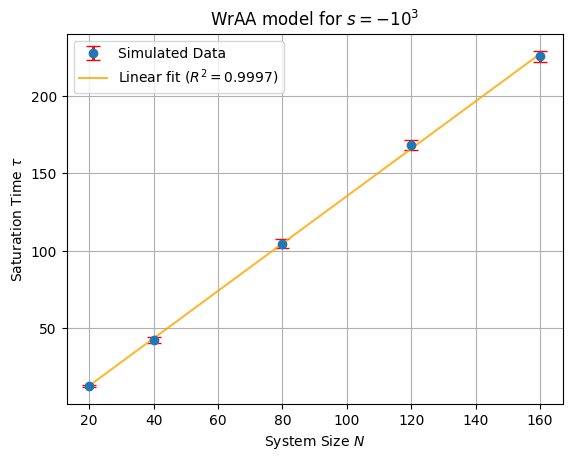

In [ ]:
# 1. Plot everything and save the results in variables
plot1 = plt.errorbar(Ns_local, tau_local, yerr=error_local, fmt='o',
                     label='Simulated Data',
                     capsize=5,          # Añade los topes horizontales (forma de "I")
                     elinewidth=2,       # Hace las líneas del error más gruesas
                     markeredgewidth=1,  # Engrosa los topes horizontales
                     ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
                     alpha=1)            # Asegura que no haya transparencia

plot2, = plt.plot(Ns_local, slope*Ns_local + intercept, alpha=0.8, color='orange',
                  label=f'Linear fit ($R^2={r_squared:.4f}$)')

# 2. Force the order in the legend
# We create a list of the plots and a list of the labels in the exact order we want
handles = [plot1, plot2]
labels = [plot1.get_label(), plot2.get_label()]

plt.legend(handles, labels, loc='best')

# 3. Rest of the formatting
plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.title(r"WrAA model for $s=-10^{3}$")
plt.grid(True)
plt.show()

### 4.2 WrAA model for $s=0$ (Non-local)

In [ ]:
# Function that corrects the previous one for fast scrambling

def saturation_time_WrAA_v2(N: int, s: float, threshold_offset: int, max_steps: int) -> int:
    """
    Measures the time 't' required for the entanglement entropy to reach saturation.
    In physics, this represents how fast the quantum information 'scrambles'
    across the entire system.
    """
    # The target entropy (threshold) is nearly the maximum possible (N/2).
    # We subtract a small offset because random circuits might stay slightly below
    # the absolute maximum for a few steps.
    threshold = (N // 2) - threshold_offset

    # Initialize the stabilizer state simulator
    state = stim.TableauSimulator()
    state.set_num_qubits(N)

    # CORRECCIÓN CON RESPECTO LA FUNCIÓN DE ANTES
    # Para s=0 (muy rápido), check_every debe ser 1 siempre.
    # Para s < -1 (lento), puedes usar check_every = 5 para ahorrar tiempo.

    for t in range(max_steps):
        state.do_tableau(WrAA_time_step(N, s), range(N))
        S = entanglement_entropy_half_system_fast(state)
        # If the entropy has reached the threshold, the system is 'saturated'
        if S >= threshold:
              return t + 1   # Return the time step where saturation occurred
    return max_steps    # If it never reaches the threshold, return the maximum allowed steps


def estimate_tau_vs_N_WrAA_v2(Ns, s, reps=20, threshold_offset=5, seed=0):    # Si no especifico cuántas repeticiones quiero, haré 20
    """
    Revised version to avoid the artificial plateau.
    The issue is that max_steps must be large enough to NOT interfere
    with the actual physical saturation time.
    """
    if seed is not None:
        np.random.seed(seed)

    tau_mean = []
    tau_error = []
    for N in Ns:
        # INCREASE THIS: If tau seems to plateau, it's often because
        # it's hitting the 'max_steps' ceiling.
        # For N=200, let's allow more room.
        max_steps = int(10 * N)

        taus = []
        for _ in range(reps):
            # If this returns 'max_steps', the simulation 'timed out'
            tau = saturation_time_WrAA_v2(N, s, threshold_offset, max_steps)
            taus.append(tau)

        # Standard Error of the Mean (SEM) formula: sigma / sqrt(n)
        # We use ddof=1 for the sample standard deviation
        taus_array = np.array(taus)
        error_val = np.std(taus_array, ddof=1) / np.sqrt(reps)

        tau_mean.append(np.mean(taus))
        tau_error.append(error_val)

    return np.array(Ns), np.array(tau_mean), np.array(tau_error)

In [ ]:
Ns = np.array([20, 40, 80, 120, 160])
Ns = Ns[Ns % 2 == 0]

reps_param = 20
offset_param = 5
steps_factor = 8.0

Ns_nonlocal, tau_nonlocal, error_nonlocal = estimate_tau_vs_N_WrAA_v2(
    Ns,
    s=0,
    reps=reps_param,
    threshold_offset=offset_param,
    seed=0
)

In [ ]:
# Regrassion

# Perform Logarithmic Transformation
# We fit: tau = slope * log(N) + intercept
log_Ns = np.log(Ns_nonlocal)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_Ns, tau_nonlocal)
r_squared = r_value**2

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (b): {intercept:.4f}")
print(f"R-squared (R²): {r_squared:.4f}")


Slope (m): 1.7792
Intercept (b): -1.9673
R-squared (R²): 0.9830


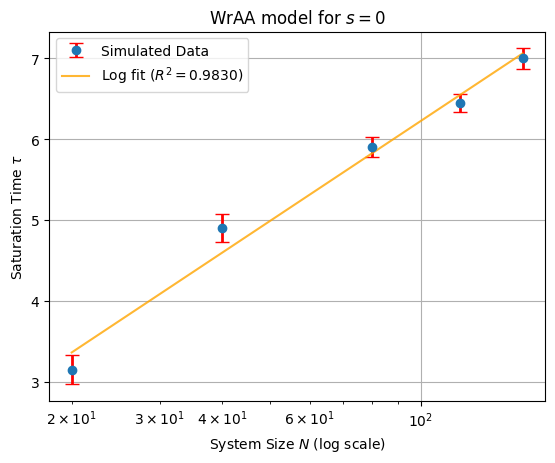

In [ ]:
# Plot Simulated Data first
plot1 = plt.errorbar(Ns_nonlocal, tau_nonlocal, yerr=error_nonlocal, fmt='o',
                     label='Simulated Data',
                     capsize=5,          # Añade los topes horizontales (forma de "I")
                     elinewidth=2,       # Hace las líneas del error más gruesas
                     markeredgewidth=1,  # Engrosa los topes horizontales
                     ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
                     alpha=1)

# Plot Logarithmic Fit in orange
plot2, = plt.plot(Ns_nonlocal, slope * np.log(Ns_nonlocal) + intercept, color='orange', alpha=0.8,
                  label=f'Log fit ($R^2={r_squared:.4f}$)')

# Manual Legend Ordering (Handles and Labels)
handles = [plot1, plot2]
labels = [h.get_label() for h in handles]
plt.legend(handles, labels, loc='best')

plt.xlabel(r"System Size $N$ (log scale)")
plt.ylabel(r"Saturation Time $\tau$")
plt.title(r"WrAA model for $s=0$")
plt.grid(True)

plt.xscale('log')

plt.show()

Analisis for different threeshold:

In [ ]:
# Local case

def estimate_tau_vs_N_multi_offset(Ns, s, offsets, steps_factor, reps=20, seed=0):
    """
    Analyzes how the saturation time scales for different threshold offsets (epsilon).
    Returns a dictionary where each key is an offset and each value is (tuple of means and errors).
    """
    results = {}

    for eps in offsets:
        _, means, errors = estimate_tau_vs_N_WrAA(
            Ns,
            s,
            reps=reps,
            threshold_offset=eps,
            max_steps_factor=steps_factor,
            seed=seed
        )
        results[eps] = (means, errors)

    return results


# Non local case

def estimate_tau_vs_N_multi_offset_v2(Ns, s, offsets, reps=20, seed=0):
    """
    Analyzes how the saturation time scales for different threshold offsets (epsilon).
    Returns a dictionary where each key is an offset and each value is (means, errors).
    """
    results = {}

    for eps in offsets:
        # We reuse your existing estimation function for each offset
        _, means, errors = estimate_tau_vs_N_WrAA_v2(
            Ns, s, reps=reps, threshold_offset=eps, seed=seed
        )
        results[eps] = (means, errors)

    return results

In [ ]:
# --- Common Parameters ---
Ns = np.array([20, 40, 60, 80, 120])
epsilons = [1, 2, 4, 8]
reps_param = 10


# ---------------------------------------------------------
# FIGURE 1: LOCAL CASE (s = -10**3)
# ---------------------------------------------------------

s_local = -(10**3)
steps_factor_local = 8.0

data_local = estimate_tau_vs_N_multi_offset(
    Ns, s_local, epsilons, steps_factor_local, reps=reps_param, seed=0
)


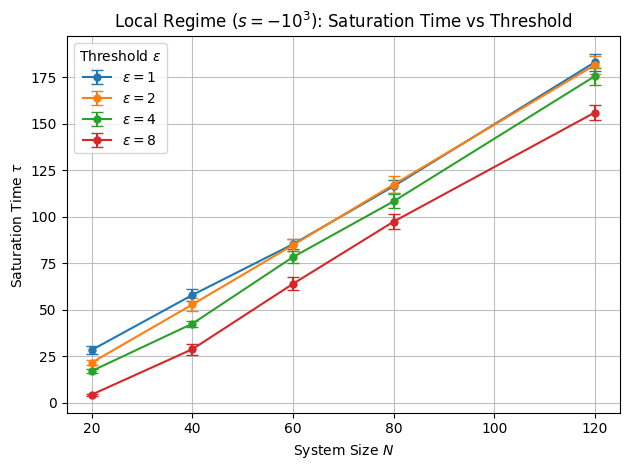

In [ ]:
plt.figure()
for eps in epsilons:
    means, errors = data_local[eps]
    plt.errorbar(Ns, means, yerr=errors, fmt='o-', capsize=4,
                 linewidth=1.5, markersize=5, label=rf'$\epsilon = {eps}$')

plt.title(f"Local Regime ($s=-10^{3}$): Saturation Time vs Threshold")
plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.legend(title=r"Threshold $\epsilon$", frameon=True)
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# --- Common Parameters ---
Ns = np.array([20, 40, 60, 80, 120])
epsilons = [1, 2, 4, 8]
reps_param = 20


# =========================================================
# FIGURE 2: NON-LOCAL CASE (s = 0.0)
# =========================================================

s_nonlocal = 0.0


results_nonlocal = {}

for eps in epsilons:
    _, m, e = estimate_tau_vs_N_WrAA_v2(
        Ns, s_nonlocal, reps=reps_param, threshold_offset=eps, seed=0
    )
    results_nonlocal[eps] = (m, e)


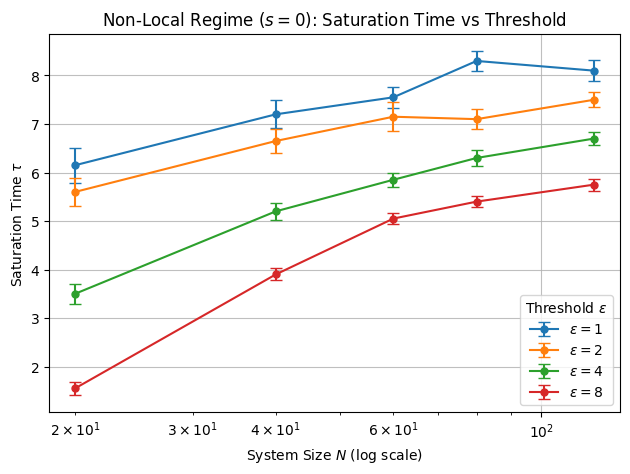

In [ ]:
plt.figure()
for eps in epsilons:
    means, errors = results_nonlocal[eps]
    plt.errorbar(Ns, means, yerr=errors, fmt='o-', capsize=4,
                 linewidth=1.5, markersize=5, label=rf'$\epsilon = {eps}$')

plt.title(f"Non-Local Regime ($s=0$): Saturation Time vs Threshold")
plt.xlabel(r"System Size $N$ (log scale)")
plt.ylabel(r"Saturation Time $\tau$")
plt.legend(title=r"Threshold $\epsilon$", frameon=True)
plt.grid(True, alpha=0.8)
plt.tight_layout()
plt.xscale('log')
plt.show()

### 4.3 Saturation time behavior: $\quad\tau\sim a(s)N^{f(s)} $

In [ ]:
# We will stimate f(s)


def estimate_tau_linear_scaling(Ns, s, reps=20, frac=0.8):
    """
    Computes the average saturation time for different system sizes.
    Uses a linear max_steps (2*N) to correctly capture the local regime behavior.
    Esta función engloba las anteriores pero es más rápida puesto que no llama otras funciones
    """
    tau_mean = []
    for N in Ns:
        # We allow enough time for local entanglement waves to travel the whole system
        max_steps = 2 * N
        # The threshold is a fraction (e.g., 80%) of the maximum possible entropy (N/2)
        threshold = int(frac * (N // 2))
        taus = []

        for _ in range(reps):
            state = stim.TableauSimulator()
            state.set_num_qubits(N)
            found = False

            for t in range(max_steps):
                state.do_tableau(WrAA_time_step(N, s), range(N))

                # OPTIMIZATION: Entropy calculation is slow.
                # We only check the state every 5 steps to save CPU time.
                if (t + 1) % 5 == 0 or t == max_steps - 1:
                    S = entanglement_entropy_half_system_fast(state)
                    if S >= threshold:
                        taus.append(t + 1)
                        found = True
                        break

            # If it never saturated, we record the maximum time used
            if not found:
                taus.append(max_steps)

        # Average the results for this specific N
        tau_mean.append(np.mean(taus))

    return np.array(tau_mean)



import concurrent.futures



def process_single_s(args):
    """
    Helper function to process a single 's' value.
    It calculates the scaling exponent f(s) by performing a log-log fit.
    """
    s_val, Ns, reps = args
    # 1. Get the average saturation times for all N
    taus = estimate_tau_linear_scaling(Ns, s_val, reps=reps)

    # 2. LOG-LOG FIT: In physics, if tau = N^f, then log(tau) = f * log(N).
    # np.polyfit calculates the slope 'f', which is our f(s) exponent.
    f_s, _ = np.polyfit(np.log(Ns), np.log(taus), 1)

    print(f"Finished s={s_val:>5.1f} | f(s)={f_s:.4f}")
    return f_s



def calculate_exponents_PARALLEL(s_values, Ns, reps=25):
    """
    Executes the simulation for multiple 's' values simultaneously using all CPU cores.
    This drastically reduces the total execution time.
    """
    # Prepare the list of tasks (each task is one value of s)
    tasks = [(s, Ns, reps) for s in s_values]

    # ProcessPoolExecutor launches different Python processes in parallel
    with concurrent.futures.ProcessPoolExecutor() as executor:
        # Map applies 'process_single_s' to every task in our list
        results = list(executor.map(process_single_s, tasks))

    return np.array(results)

El ajuste $\log(Ns)$ vs $\log(\tau)$ es la forma estándar de medir cómo crece una magnitud. Si la línea resultante es una diagonal de 45 grados, $f=1$ (lineal). Si es plana, $f=0$ (logarítmico).

Parallel simulation:
Finished s= -3.0 | f(s)=0.8113
Finished s= -2.0 | f(s)=0.3688
Finished s= -1.0 | f(s)=0.1158
Finished s= -0.6 | f(s)=0.0604
Finished s=  0.0 | f(s)=-0.0049
Finished s= -5.0 | f(s)=0.9553


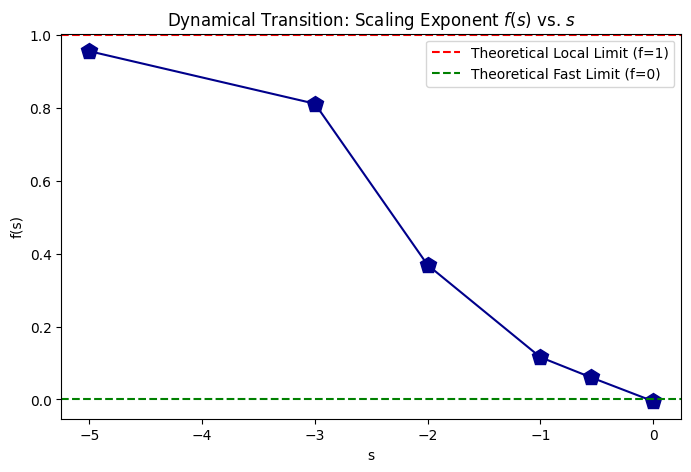

In [ ]:
# Execution and plot

if __name__ == '__main__':     # It is mandatory when using parallel processing (PARALLEL)
    s_plot = [-5.0, -3.0, -2.0, -1.0, -0.55, 0.0]
    Ns_plot = [20, 40, 80, 160]

    print("Parallel simulation:")
    f_values = calculate_exponents_PARALLEL(s_plot, Ns_plot, reps=20)

    plt.figure(figsize=(8, 5))
    plt.plot(s_plot, f_values, 'p-', markersize=12, color='darkblue')

    # Reference lines for theoretical limits:
    # f=1 means the scrambling time is proportional to N (Local dynamics)
    plt.axhline(1, color='red', linestyle='--', label='Theoretical Local Limit (f=1)')
    # f=0 means the scrambling time is proportional to log(N) (Fast Scrambling)
    plt.axhline(0, color='green', linestyle='--', label='Theoretical Fast Limit (f=0)')

    plt.title("Dynamical Transition: Scaling Exponent $f(s)$ vs. $s$")
    plt.xlabel("s")
    plt.ylabel("f(s)")
    plt.legend()
    plt.show()

Plots for different cases pf the parameter s:

In [ ]:
Ns = np.array([20, 40, 80, 120, 160, 200, 256])
Ns = Ns[Ns % 2 == 0]

reps_param = 20
offset_param = 5
steps_factor = 8.0

Ns_local2, tau_local2, error_local2= estimate_tau_vs_N_WrAA(
    Ns,
    s=-2,
    reps=reps_param,
    threshold_offset=offset_param,
    max_steps_factor=steps_factor,
    seed=0
)

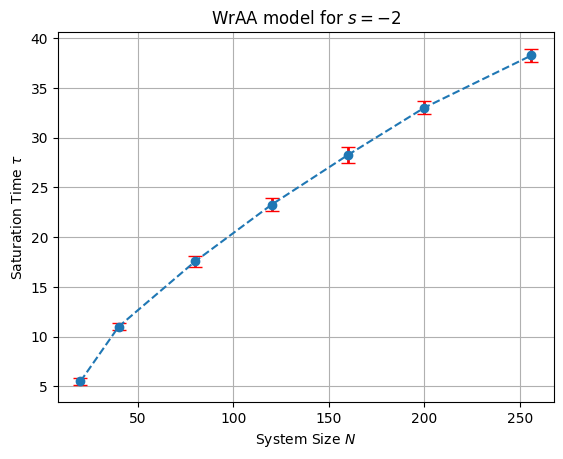

In [ ]:
plt.errorbar(Ns_local2, tau_local2, yerr=error_local2, fmt='o--',
             capsize=5,          # Añade los topes horizontales (forma de "I")
             elinewidth=2,       # Hace las líneas del error más gruesas
             markeredgewidth=1,  # Engrosa los topes horizontales
             ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
             alpha=1)            # Asegura que no haya transparencia
plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.title(r"WrAA model for $s=-2$")
plt.grid(True)
plt.show()

In [ ]:
Ns = np.array([20, 40, 80, 120, 160, 200, 256])
Ns = Ns[Ns % 2 == 0]

reps_param = 10
offset_param = 5
steps_factor = 8.0

Ns_local4, tau_local4, error_local4 = estimate_tau_vs_N_WrAA(
    Ns,
    s=-4,
    reps=reps_param,
    threshold_offset=offset_param,
    max_steps_factor=steps_factor,
    seed=0
)

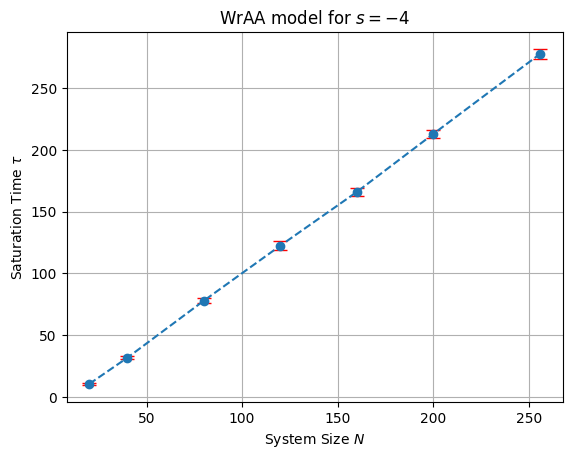

In [ ]:
plt.errorbar(Ns_local4, tau_local4, yerr=error_local4, fmt='o--',
             capsize=5,          # Añade los topes horizontales (forma de "I")
             elinewidth=2,       # Hace las líneas del error más gruesas
             markeredgewidth=1,  # Engrosa los topes horizontales
             ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
             alpha=1)            # Asegura que no haya transparencia

plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.title(r"WrAA model for $s=-4$")
plt.grid(True)
plt.show()

In [ ]:
Ns = np.array([20, 40, 80, 120, 160, 200, 256])
Ns = Ns[Ns % 2 == 0]

reps_param = 20
offset_param = 5

Ns_nonlocal0, tau_nonlocal0, error_nonlocal0 = estimate_tau_vs_N_WrAA_v2(
    Ns,
    s=0,
    reps=reps_param,
    threshold_offset=offset_param,
    seed=0
)

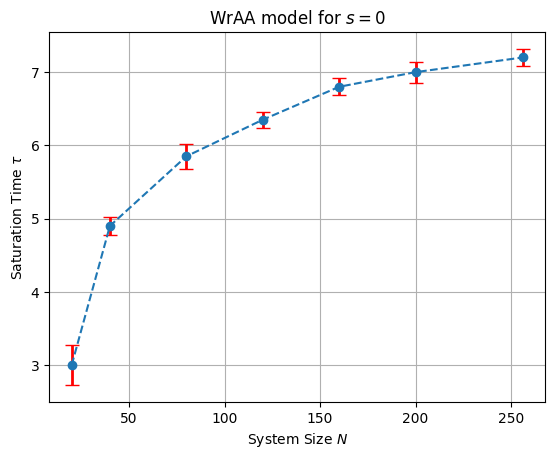

In [ ]:
plt.errorbar(Ns_nonlocal0, tau_nonlocal0, yerr=error_nonlocal0, fmt='o--',
             capsize=5,          # Añade los topes horizontales (forma de "I")
             elinewidth=2,       # Hace las líneas del error más gruesas
             markeredgewidth=1,  # Engrosa los topes horizontales
             ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
             alpha=1)            # Asegura que no haya transparencia

#plt.xscale('log')
plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.title(r"WrAA model for $s=0$")
plt.grid(True)
plt.show()

In [ ]:
Ns = np.array([20, 40, 80, 120, 160, 200, 256])
Ns = Ns[Ns % 2 == 0]

reps_param = 20
offset_param = 5

Ns_nonlocal5, tau_nonlocal5, error_nonlocal5 = estimate_tau_vs_N_WrAA_v2(
    Ns,
    s=-0.5,
    reps=reps_param,
    threshold_offset=offset_param,
    seed=0
)

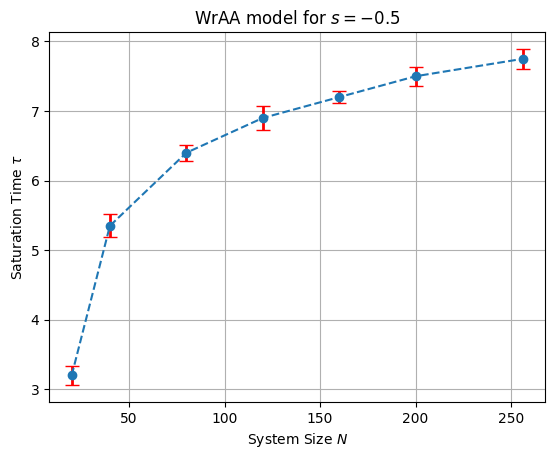

In [ ]:
plt.errorbar(Ns_nonlocal5, tau_nonlocal5, yerr=error_nonlocal5, fmt='o--',
             capsize=5,          # Añade los topes horizontales (forma de "I")
             elinewidth=2,       # Hace las líneas del error más gruesas
             markeredgewidth=1,  # Engrosa los topes horizontales
             ecolor='red',       # Puedes poner las barras en otro color (ej. rojo)
             alpha=1)            # Asegura que no haya transparencia

#plt.xscale('log')
plt.xlabel(r"System Size $N$")
plt.ylabel(r"Saturation Time $\tau$")
plt.title(r"WrAA model for $s=-0.5$")
plt.grid(True)
plt.show()

### 4.4 Tripartite mutual information

In [ ]:
## Functions


def entanglement_entropy_subsystem(state: stim.TableauSimulator, subsystem):
    """
    Computes S(subsystem) for a stabilizer state using
    S = rank(M_sub) - |subsystem|.
    If S = 0, the subsystem is in a pure state (not entangled with the rest).
    """
    subsystem = list(subsystem)
    stabs = state.canonical_stabilizers()
    rows = restricted_rows_as_ints_from_stabilizers(stabs, subsystem)
    r = gf2_rank_int(rows)
    return r - len(subsystem)



def tripartite_mutual_information(state: stim.TableauSimulator, A, B, C):
    """
    Computes the Tripartite Mutual Information (I3) between three regions.
    I3 measures 'scrambling': how information is distributed across the system.

    I3 = S_A + S_B + S_C - S_AB - S_AC - S_BC + S_ABC

    - If I3 is near 0: Information is local or only shared in simple pairs.
    - If I3 is negative: Information is delocalized (scrambled) across A, B, and C.
    """
    A = list(A)
    B = list(B)
    C = list(C)

    # Define the combined regions (unions of A, B, and C)
    AB = sorted(A + B)
    AC = sorted(A + C)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_A = entanglement_entropy_subsystem(state, A)
    S_B = entanglement_entropy_subsystem(state, B)
    S_C = entanglement_entropy_subsystem(state, C)
    S_AB = entanglement_entropy_subsystem(state, AB)
    S_AC = entanglement_entropy_subsystem(state, AC)
    S_BC = entanglement_entropy_subsystem(state, BC)
    S_ABC = entanglement_entropy_subsystem(state, ABC)

    return S_A + S_B + S_C - S_AB - S_AC - S_BC + S_ABC



def contiguous_quarter_partitions(N):
  """
  Divides the total system of N qubits into four equal, contiguous parts.
  This setup (A, B, C, D) is the standard protocol used in the paper
  to study the scrambling transition.
  """
  if N % 4 != 0:
      raise ValueError("N must be divisible by 4.")

  q = N // 4
  A = list(range(0, q))
  B = list(range(q, 2*q))
  C = list(range(2*q, 3*q))
  D = list(range(3*q, 4*q))
  return A, B, C, D



def I3_after_WrAA_one_realization(N: int, s: float, steps=None):
    """
    Executes a single simulation run (realization) of the WrAA model.
    It prepares the state, evolves it for a set number of steps, and
    measures the I3 to see how much 'scrambling' has occurred.
    """
    state = stim.TableauSimulator()
    state.set_num_qubits(N)
    A, B, C, D = contiguous_quarter_partitions(N)   # Divide the N qubits into 4 equal regions: A, B, C, and D

    # Time Evolution:
    # We use 'steps = 4' as a default to allow the information to propagate
    # across the subsystems (A, B, C) and clear the noise of a single step.
    # If we do not specify steps, we use a value that allows us to observe scrambling
    if steps is None:
        steps = 4 # Try with 4 steps instead of 1

    for _ in range(steps):
        state.do_tableau(WrAA_time_step(N, s), range(N))

    return tripartite_mutual_information(state, A, B, C)



def average_I3_vs_s_for_N(N: int, s_values, reps: int, steps=4, seed=None):
    """
    Runs multiple realizations for each 's' and returns both the mean
    and the standard error of the mean (SEM) for I3.
    """
    if seed is not None:
        np.random.seed(seed)

    vals_mean = []
    vals_error = []

    for s in s_values:
        # For each 's', repeat the experiment 'reps' times
        # More reps = smoother curves in the final plot
        vals = [I3_after_WrAA_one_realization(N, s, steps=steps) for _ in range(reps)]    #Esta forma es más rápida.
                                        # Aquí el for dice que calcules I3 20 veces (si reps=20). Luego, todos los números obtenidos
                                        # se recogen en la lista vals. Por último hacemos la media.

        # Calculate the average (mean) I3 for this specific s and N
        vals_array = np.array(vals)
        vals_mean.append(np.mean(vals_array))

        # Calculate Standard Error: sigma / sqrt(reps)
        # Using ddof=1 for the sample standard deviation
        error = np.std(vals_array, ddof=1) / np.sqrt(reps)
        vals_error.append(error)

    return np.array(vals_mean), np.array(vals_error)

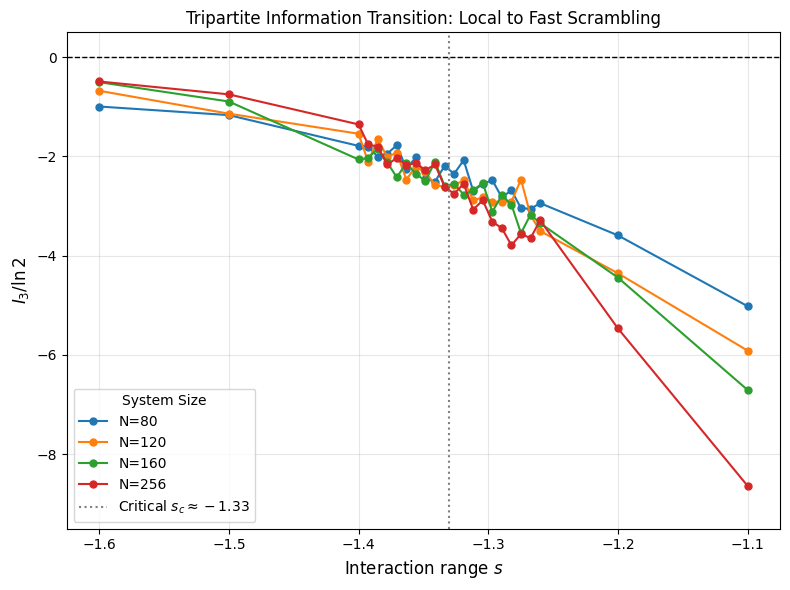

In [ ]:
# We define a range of s closer to the transition (-1.33)
s_extremos = [-1.6, -1.5, -1.2, -1.1]  # Far values of s
s_critico = np.linspace(-1.4, -1.26, 20) # Close values to s_c=-1.33
s_values = np.unique(np.sort(np.concatenate([s_extremos, s_critico]))) # We merge, remove duplicates, and sort

Ns = [80, 120, 160, 256]

plt.figure(figsize=(8, 6))

for N in Ns:
    # Calculate I3
    I3_raw = average_I3_vs_s_for_N(N, s_values, reps=100, steps=4, seed=0)
    # NORMALIZATION: the paper uses I3 / ln(2)
    I3_normalized = I3_raw / np.log(2)

    plt.plot(s_values, I3_normalized, 'o-', markersize=5, label=f'N={N}')

# Visual references
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(-1.33, color='gray', linestyle=':', label='Critical $s_c \\approx -1.33$')

plt.xlabel(r'Interaction range $s$', fontsize=12)
plt.ylabel(r'$I_3 / \ln 2$', fontsize=12)
plt.title(r'Tripartite Information Transition: Local to Fast Scrambling')

plt.grid(True, alpha=0.3)
plt.legend(title="System Size", loc='lower left')

plt.ylim(min(I3_normalized)*1.1, 0.5)

plt.tight_layout()
plt.show()

In [ ]:
# This is to calculate I3 faster for high values of reps

def process_single_N_I3(N, s_values, reps, steps):
    """Worker function to process a single N across all s_values."""
    # This calls your existing averaging function
    return average_I3_vs_s_for_N(N, s_values, reps=reps, steps=steps)

def calculate_I3_PARALLEL(Ns, s_values, reps=50, steps=4):
    """Distributes the I3 calculation for different Ns across CPU cores."""
    # Create a list of arguments for each process
    args = [(N, s_values, reps, steps) for N in Ns]

    # Use all available CPU cores
    with Pool(processes=cpu_count()) as pool:
        # starmap allows passing multiple arguments to the function
        results = pool.starmap(process_single_N_I3, args)

    return results

Starting parallel I3 simulation using 2 cores...


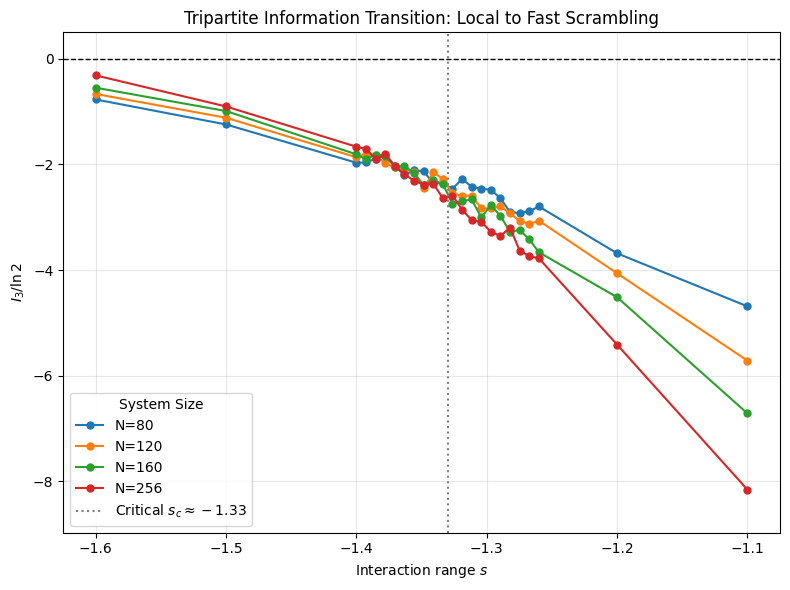

In [ ]:
if __name__ == '__main__':
    s_extremos = [-1.6, -1.5, -1.2, -1.1]
    s_critico = np.linspace(-1.4, -1.26, 20)
    s_values = np.unique(np.sort(np.concatenate([s_extremos, s_critico])))
    Ns = [80, 120, 160, 256]
    reps = 500
    steps = 4

    print(f"Starting parallel I3 simulation using {cpu_count()} cores...")

    # RUN IN PARALLEL
    # all_results will be a list of arrays: [I3_N80, I3_N120, I3_N160, I3_N256]
    all_results = calculate_I3_PARALLEL(Ns, s_values, reps=reps, steps=steps)

    # PLOTTING
    plt.figure(figsize=(8, 6))

    # We zip Ns and results to plot them together
    for N, I3_raw in zip(Ns, all_results):
        I3_normalized = I3_raw / np.log(2)
        plt.plot(s_values, I3_normalized, 'o-', markersize=5, label=f'N={N}')

    # Visual references
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.axvline(-1.33, color='gray', linestyle=':', label='Critical $s_c \\approx -1.33$')
    plt.xlabel(r'Interaction range $s$')
    plt.ylabel(r'$I_3 / \ln 2$')
    plt.title(r'Tripartite Information Transition: Local to Fast Scrambling')
    plt.grid(True, alpha=0.3)
    plt.legend(title="System Size", loc='lower left')

    # Dynamic Y limit based on the very last result
    plt.ylim(np.min(all_results[-1]/np.log(2))*1.1, 0.5)

    plt.tight_layout()
    plt.show()

Starting parallel I3 simulation using 2 cores...


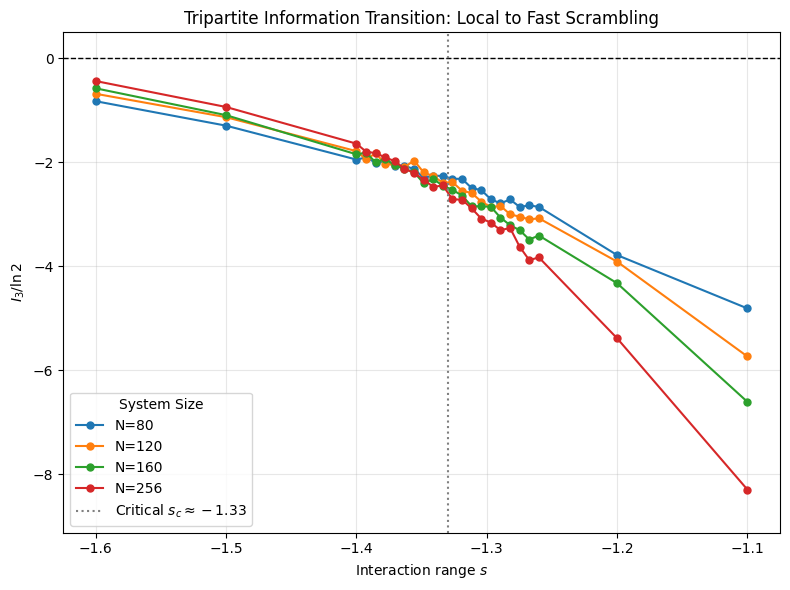

In [ ]:
if __name__ == '__main__':
    s_extremos = [-1.6, -1.5, -1.2, -1.1]
    s_critico = np.linspace(-1.4, -1.26, 20)
    s_values = np.unique(np.sort(np.concatenate([s_extremos, s_critico])))
    Ns = [80, 120, 160, 256]
    reps = 1000
    steps = 4

    print(f"Starting parallel I3 simulation using {cpu_count()} cores...")

    # RUN IN PARALLEL
    # all_results will be a list of arrays: [I3_N80, I3_N120, I3_N160, I3_N256]
    all_results = calculate_I3_PARALLEL(Ns, s_values, reps=reps, steps=steps)

    # PLOTTING
    plt.figure(figsize=(8, 6))

    # We zip Ns and results to plot them together
    for N, I3_raw in zip(Ns, all_results):
        I3_normalized = I3_raw / np.log(2)
        plt.plot(s_values, I3_normalized, 'o-', markersize=5, label=f'N={N}')

    # Visual references
    plt.axhline(0, color='black', linewidth=1, linestyle='--')
    plt.axvline(-1.33, color='gray', linestyle=':', label='Critical $s_c \\approx -1.33$')
    plt.xlabel(r'Interaction range $s$')
    plt.ylabel(r'$I_3 / \ln 2$')
    plt.title(r'Tripartite Information Transition: Local to Fast Scrambling')
    plt.grid(True, alpha=0.3)
    plt.legend(title="System Size", loc='lower left')

    # Dynamic Y limit based on the very last result
    plt.ylim(np.min(all_results[-1]/np.log(2))*1.1, 0.5)


    plt.tight_layout()
    plt.show()

### Tripartite mutual information with different time steps:

In [ ]:
# Parallel but now with steps

def process_single_step_I3(N, s_values, reps,steps):
    """
    Worker function to process a single 'time step' across all s_values.
    Each process will handle one line of the final graph.
    Returns a tuple (mean_array, error_array) for a specific time step.
    """
    # This calls your existing core simulation function
    return average_I3_vs_s_for_N(N, s_values, reps=reps, steps=steps)



def calculate_I3_PARALLEL_steps(N_fixed, s_values, reps, steps_list):
    """
    Distributes calculations across CPU cores. Returns two lists:
    one with mean arrays and one with error arrays for each time step.
    """
    # 1. Create a list of arguments for each process.
    # We iterate over 'steps_list' (the iterable) while keeping N, s_values, and reps fixed.
    args = [(N_fixed, s_values, reps, t) for t in steps_list]

    # 2. Use a Pool of workers
    # 'with' ensures the pool is closed and cleaned up automatically
    with Pool(processes=cpu_count()) as pool:
        # results will be a list of tuples: [(mean1, err1), (mean2, err2), ...]
        results = pool.starmap(process_single_step_I3, args)

    # We "unzip" the results into two separate lists
    means = [r[0] for r in results]
    errors = [r[1] for r in results]

    return means, errors

Starting parallel I3 simulation using 2 cores...


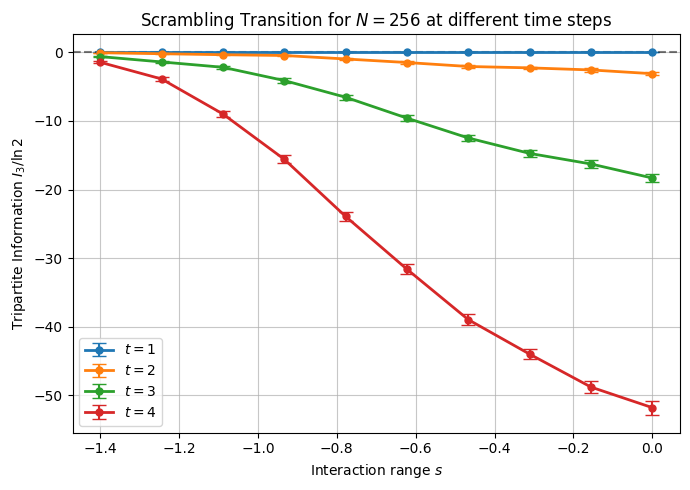

In [ ]:
if __name__ == '__main__':
    # --- Parameters ---
    s_values = np.linspace(-1.4, 0.0, 10)
    N_fixed = 256
    reps = 100
    steps_to_compare = [1, 2, 3, 4]

    # --- Run Parallel ---
    print(f"Starting parallel I3 simulation using {cpu_count()} cores...")

    # Now the function returns two separate lists: one for means and one for errors
    all_means, all_errors = calculate_I3_PARALLEL_steps(N_fixed, s_values, reps, steps_to_compare)

    # --- Plotting Code ---
    plt.figure(figsize=(7, 5))

    # Iterate over both lists using zip
    for t_idx, (I3_mean_raw, I3_err_raw) in enumerate(zip(all_means, all_errors)):
        t_val = steps_to_compare[t_idx]

        # Normalize both the mean and the error by log(2)
        I3_mean_normalized = I3_mean_raw / np.log(2)
        I3_err_normalized = I3_err_raw / np.log(2)

        # Use errorbar to visualize the statistical uncertainty
        plt.errorbar(s_values, I3_mean_normalized, yerr=I3_err_normalized,
                     fmt='o-', linewidth=2, markersize=5, capsize=5, elinewidth=1.5,
                     label=f'$t={t_val}$')

    # Add a horizontal line at 0 (Threshold for scrambling)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)

    # Labels and Aesthetics
    plt.xlabel(r'Interaction range $s$')
    plt.ylabel(r'Tripartite Information $I_3 / \ln 2$')
    plt.title(f'Scrambling Transition for $N={N_fixed}$ at different time steps')

    plt.grid(True, which='both', alpha=0.7)
    plt.legend(loc='best', frameon=True)

    plt.tight_layout()
    plt.show()

### 4.5 Fluctuations

In [ ]:
# Fluctuations

def analyze_I3_fluctuations(N: int, s_values, reps: int, steps=4):
    """
    Runs multiple realizations and returns both the average (mean)
    and the fluctuations (standard deviation) of I3.
    """
    means = []
    stds = []

    for s in s_values:
        # Collect 'reps' independent samples for this specific s
        # Underscore '_' means we don't need the loop index
        samples = [I3_after_WrAA_one_realization(N, s, steps=steps) for _ in range(reps)]

        # Calculate the ensemble average (arithmetic mean)
        means.append(np.mean(samples))

        # Calculate the fluctuations (standard deviation)
        # This measures how much individual runs deviate from the average
        stds.append(np.std(samples))

    return np.array(means), np.array(stds)



def average_I3_single_s_worker(N, s, reps, steps):
    """Worker function for a single value of s to be used in parallel."""
    vals = [I3_after_WrAA_one_realization(N, s, steps=steps) for _ in range(reps)]
    return np.mean(vals), np.std(vals, ddof=1)

In [ ]:
def i3_transition_worker(N, s, reps, steps):
    """
    Worker for a single (N, s) point.
    Returns: (mean, standard_deviation)
    """
    samples = []
    for _ in range(reps):
        samples.append(I3_after_WrAA_one_realization(N, s, steps=steps))

    samples_array = np.array(samples)
    return np.mean(samples_array), np.std(samples_array, ddof=1)

def calculate_I3_fluctuations_PARALLEL(N, s_values, reps, steps):
    """
    Parallelizes the 's' sweep for a fixed N.
    Returns: mean_array, std_array
    """
    args = [(N, s, reps, steps) for s in s_values]

    with Pool(processes=cpu_count()) as pool:
        # Results is a list of tuples: [(mean, std), (mean, std), ...]
        results = pool.starmap(i3_transition_worker, args)

    means = np.array([r[0] for r in results])
    stds = np.array([r[1] for r in results])
    return means, stds

Processing N=160 in parallel...
Processing N=256 in parallel...


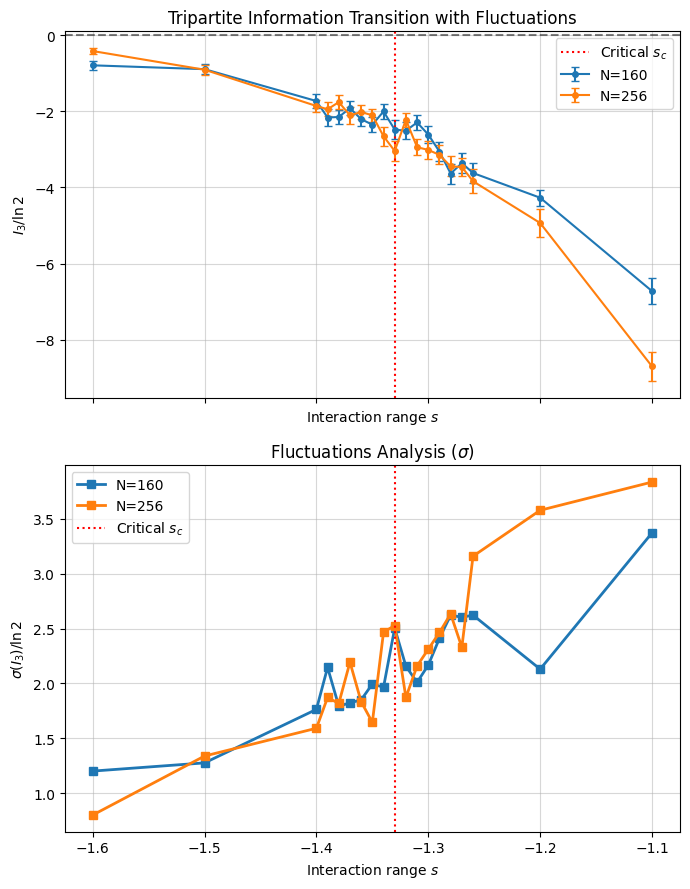

In [ ]:
if __name__ == '__main__':
    # --- 1. Setup Parameters ---
    s_extremos = [-1.6, -1.5, -1.2, -1.1]
    s_critico = np.linspace(-1.4, -1.26, 15)
    s_values = np.unique(np.sort(np.concatenate([s_extremos, s_critico])))

    Ns = [160, 256]
    reps = 100
    t_fixed = 4

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)

    for N in Ns:
        print(f"Processing N={N} in parallel...")

        # Calculate mean and fluctuations
        means, stds = calculate_I3_fluctuations_PARALLEL(N, s_values, reps, t_fixed)

        # Normalization to ln(2)
        y_mean = means / np.log(2)
        y_std = stds / np.log(2)
        y_sem = y_std / np.sqrt(reps) # Standard Error for the top plot

        # --- TOP PLOT: Scrambling Transition ---
        ax1.errorbar(s_values, y_mean, yerr=y_sem, fmt='o-',
                     capsize=3, label=f'N={N}', markersize=4)

        # --- BOTTOM PLOT: Entanglement Fluctuations ---
        ax2.plot(s_values, y_std, 's-', label=f'N={N}', linewidth=2)

    # Aesthetics for ax1 (Mean)
    ax1.set_xlabel(r"Interaction range $s$")
    ax1.set_ylabel(r"$I_3 / \ln 2$")
    ax1.set_title(r"Tripartite Information Transition with Fluctuations")
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.axvline(-1.33, color='red', linestyle=':', label='Critical $s_c$')
    ax1.legend()
    ax1.grid(True, alpha=0.5)

    # Aesthetics for ax2 (Fluctuations)
    ax2.set_xlabel(r"Interaction range $s$")
    ax2.set_ylabel(r"$\sigma(I_3) / \ln 2$")
    ax2.set_title(r"Fluctuations Analysis ($\sigma$)")
    ax2.axvline(-1.33, color='red', linestyle=':', label='Critical $s_c$')
    ax2.legend()
    ax2.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()

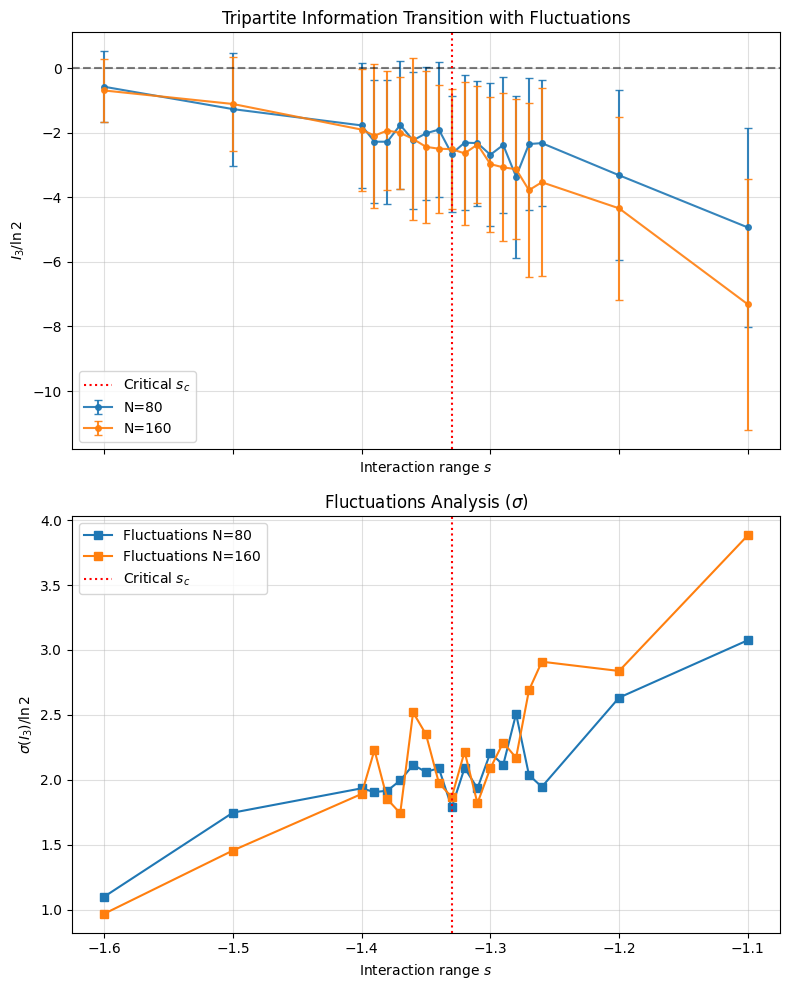

In [ ]:
# Execution

if __name__ == '__main__':
    # Define a dense range around the critical point s = -1.33
    s_extremos = [-1.6, -1.5, -1.2, -1.1]  # Far values of s
    s_critico = np.linspace(-1.4, -1.26, 15) # Close values to s_c=-1.33
    s_values = np.unique(np.sort(np.concatenate([s_extremos, s_critico]))) # We merge, remove duplicates, and sort

    Ns = [80, 160]  # We use two system sizes to compare how fluctuations scale with N
    reps = 100

    # We create a figure with two subplots: one for I3 and one for Fluctuations
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

    for N in Ns:
        means, stds = analyze_I3_fluctuations(N, s_values, reps=reps)  # Run simulation

        # Normalize by ln(2) to match the paper's units
        y_mean = means / np.log(2)
        y_err = stds / np.log(2)

        # TOP PLOT: Average I3 with Error Bars
        # The 'yerr' represents the fluctuations around the mean. RECUERDA: ERROR ESTÁNDAR DE LA MEDIA
        ax1.errorbar(s_values, y_mean, yerr=y_err/(np.sqrt(reps)), fmt='o-', markersize=4,
                     capsize=3, label=f'N={N}', alpha=0.9)

        # BOTTOM PLOT: Fluctuations (standard deviation)
        ax2.plot(s_values, y_err, 's-', label=f'Fluctuations N={N}')

    # Mean I3 plot
    ax1.set_xlabel(r"Interaction range $s$")
    ax1.set_ylabel(r"$I_3 / \ln 2$")
    ax1.set_title(r"Tripartite Information Transition with Fluctuations")
    ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax1.axvline(-1.33, color='red', linestyle=':', label='Critical $s_c$')
    ax1.legend()
    ax1.grid(True, alpha=0.4)

    # Fluctuations plot
    ax2.set_xlabel(r"Interaction range $s$")
    ax2.set_ylabel(r"$\sigma(I_3) / \ln 2$")
    ax2.set_title(r"Fluctuations Analysis ($\sigma$)")
    ax2.axvline(-1.33, color='red', linestyle=':', label='Critical $s_c$')
    ax2.legend()
    ax2.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()